# In vivo temperature measurements analysis

In [1]:
%load_ext autoreload
%autoreload 2

### Imports

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from usnm2p.logger import logger
from usnm2p.constants import *
from usnm2p.thermal_utils import *
from usnm2p.fileops import *

### Inputs

In [3]:
dataroot = '/Users/tlemaire/Documents/data/US_thermal_experiments'
# experiment = '20260910_M01'  
experiment = '20260911_M02'
datadir = os.path.join(dataroot, experiment)

# Root directory for output figures
figsdir = os.path.join(dataroot, 'figs')
if not os.path.exists(figsdir):
    os.makedirs(figsdir)
logger.info(f'output figures directory: "{figsdir}"')

# Figures dictionary
figs = {}

 2026/09/15 15:33:10: output figures directory: "/Users/tlemaire/Documents/data/US_thermal_experiments/figs"


### Load data

 2026/09/15 15:33:10: loading info from "/Users/tlemaire/Documents/data/US_thermal_experiments/20260911_M02/v1_center_300um" recording
 2026/09/15 15:33:10: getting sample rate from info.rhd header
 2026/09/15 15:33:10: Intan RHD version: 1.5
 2026/09/15 15:33:10: Intan RHD sample rate: 20000.0 Hz
 2026/09/15 15:33:10: Intan RHD board mode: 0
 2026/09/15 15:33:10: getting sample count and analog channel count from file sizes
 2026/09/15 15:33:10: sample count: 18714960, analog channel count: 1
 2026/09/15 15:33:10: loading analogin.dat as memmap
 2026/09/15 15:33:10: downsampling channel 0 from 20000.0 Hz to 119.760 Hz
 2026/09/15 15:33:11: converting downsampled ADC vector to volts
 2026/09/15 15:33:11: generating downsampled time vector
 2026/09/15 15:33:11: converting Osensa probe voltage to °C
 2026/09/15 15:33:11: Lowpass filtering temperature trace at 30 Hz
 2026/09/15 15:33:11: plotting longitudinal temperature recording at 3.992 Hz
 2026/09/15 15:33:11: loading digitalin.dat as

T (°C)  \
location                trial time (s)                
v1_center_300um         0     -0.491925   66.500805   
                              -0.483575   66.496709   
                              -0.475225   66.493423   
                              -0.466875   66.495932   
                              -0.458525   66.496319   
...                                             ...   
v1_lateral_1000um_300um 179    19.497825  58.896521   
                               19.506175  58.894318   
                               19.514525  58.889991   
                               19.522875  58.888834   
                               19.531225  58.896484   

                                                          timestamp  \
location                trial time (s)                                
v1_center_300um         0     -0.491925  2026-09-11 11:22:39.624068   
                              -0.483575  2026-09-11 11:22:39.624068   
                              -0.475225  2026-09-11 11:22:39.624068   
                              -0.466875  2026-09-11 11:22:39.624068   
                              -0.458525  2026-09-11 11:22:39.624068   
...                                                             ...   
v1_lateral_1000um_300um 179    19.497825 2026-09-11 12:32:14.180217   
                               19.506175 2026-09-11 12:32:14.180217   
                               19.514525 2026-09-11 12:32:14.180217   
                               19.522875 2026-09-11 12:32:14.180217   
                               19.531225 2026-09-11 12:32:14.180217   

                                          Fdrive (MHz)  P (MPa)   Vpp (V)  \
location                trial time (s)                                      
v1_center_300um         0     -0.491925          2.095      0.4  0.127648   
                              -0.483575          2.095      0.4  0.127648   
                              -0.475225          2.095      0.4  0.127648   
                              -0.466875          2.095      0.4  0.127648   
                              -0.458525          2.095      0.4  0.127648   
...                                                ...      ...       ...   
v1_lateral_1000um_300um 179    19.497825         2.095      0.0  0.000000   
                               19.506175         2.095      0.0  0.000000   
                               19.514525         2.095      0.0  0.000000   
                               19.522875         2.095      0.0  0.000000   
                               19.531225         2.095      0.0  0.000000   

                                          tstim (s)  PRF (Hz)  DC (%)  \
location                trial time (s)                                  
v1_center_300um         0     -0.491925         0.2     100.0    80.0   
                              -0.483575         0.2     100.0    80.0   
                              -0.475225         0.2     100.0    80.0   
                              -0.466875         0.2     100.0    80.0   
                              -0.458525         0.2     100.0    80.0   
...                                             ...       ...     ...   
v1_lateral_1000um_300um 179    19.497825        0.2     100.0    80.0   
                               19.506175        0.2     100.0    80.0   
                               19.514525        0.2     100.0    80.0   
                               19.522875        0.2     100.0    80.0   
                               19.531225        0.2     100.0    80.0   

                                          elapsed time (s)  
location                trial time (s)                      
v1_center_300um         0     -0.491925           0.000000  
                              -0.483575           0.000000  
                              -0.475225           0.000000  
                              -0.466875           0.000000  
                              -0.458525           0.000000  
...                       

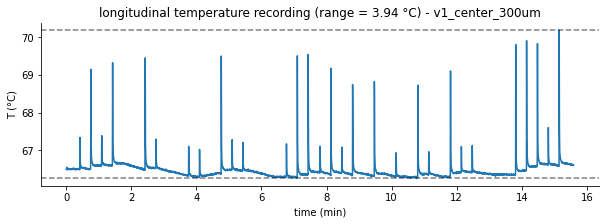

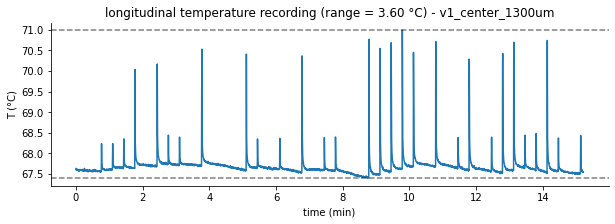

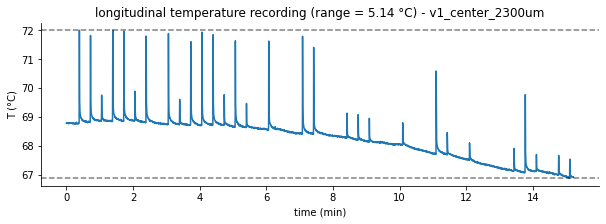

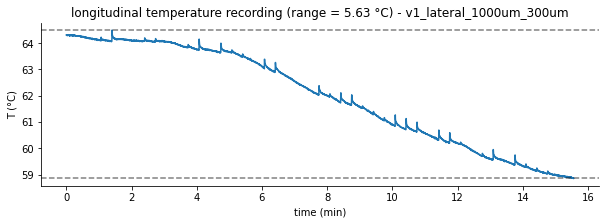

In [4]:
# Load and process the thermal experiment data
data = load_and_process_thermal_experiment(datadir, plot=True, figdict=figs)

# Rename "condition" index dimension (from different recording files) to "location"
data = data.rename_axis(index={'condition': 'location'})

logger.info('processed experiment data:')
data

### Apply trial-by-trial linear detrending and compute evoked temperature change 

In [5]:
# Restrict trial data to up to 5s post-stimulation
logger.info('restricting trial data to up to 5s post-stimulation')
data = data[data.index.get_level_values(TIME_KEY) < 5.].copy()

# Apply trial-by-trial linear detrending to the temperature data
logger.info('detrending temperature traces trial-by-trial')
data[f'detrended {TEMP_KEY}'] = (
    data
    .groupby('trial')
    [TEMP_KEY]
    .transform(detrend_trial)
)

# Compute trial-by-trial relative temperature change
logger.info('computing trial-by-trial relative temperature change')
data[REL_TEMP_KEY] = (
    data
    .groupby('trial')
    [f'detrended {TEMP_KEY}']
    .transform(compute_deltaT)
)

data

 2026/09/15 15:33:12: restricting trial data to up to 5s post-stimulation
 2026/09/15 15:33:12: detrending temperature traces trial-by-trial
 2026/09/15 15:33:13: computing trial-by-trial relative temperature change


T (°C)                  timestamp  \
location                trial time (s)                                          
v1_center_300um         0     -0.491925  66.500805 2026-09-11 11:22:39.624068   
                              -0.483575  66.496709 2026-09-11 11:22:39.624068   
                              -0.475225  66.493423 2026-09-11 11:22:39.624068   
                              -0.466875  66.495932 2026-09-11 11:22:39.624068   
                              -0.458525  66.496319 2026-09-11 11:22:39.624068   
...                                            ...                        ...   
v1_lateral_1000um_300um 179    4.960475  58.945226 2026-09-11 12:32:14.180217   
                               4.968825  58.948836 2026-09-11 12:32:14.180217   
                               4.977175  58.949652 2026-09-11 12:32:14.180217   
                               4.985525  58.946756 2026-09-11 12:32:14.180217   
                               4.993875  58.948042 2026-09-11 12:32:14.180217   

                                         Fdrive (MHz)  P (MPa)   Vpp (V)  \
location                trial time (s)                                     
v1_center_300um         0     -0.491925         2.095      0.4  0.127648   
                              -0.483575         2.095      0.4  0.127648   
                              -0.475225         2.095      0.4  0.127648   
                              -0.466875         2.095      0.4  0.127648   
                              -0.458525         2.095      0.4  0.127648   
...                                               ...      ...       ...   
v1_lateral_1000um_300um 179    4.960475         2.095      0.0  0.000000   
                               4.968825         2.095      0.0  0.000000   
                               4.977175         2.095      0.0  0.000000   
                               4.985525         2.095      0.0  0.000000   
                               4.993875         2.095      0.0  0.000000   

                                         tstim (s)  PRF (Hz)  DC (%)  \
location                trial time (s)                                 
v1_center_300um         0     -0.491925        0.2     100.0    80.0   
                              -0.483575        0.2     100.0    80.0   
                              -0.475225        0.2     100.0    80.0   
                              -0.466875        0.2     100.0    80.0   
                              -0.458525        0.2     100.0    80.0   
...                                            ...       ...     ...   
v1_lateral_1000um_300um 179    4.960475        0.2     100.0    80.0   
                               4.968825        0.2     100.0    80.0   
                               4.977175        0.2     100.0    80.0   
                               4.985525        0.2     100.0    80.0   
                               4.993875        0.2     100.0    80.0   

                                         elapsed time (s)  detrended T (°C)  \
location                trial time (s)                                        
v1_center_300um         0     -0.491925          0.000000         66.531021   
                              -0.483575          0.000000         66.526856   
                              -0.475225          0.000000         66.523501   
                              -0.466875          0.000000         66.525940   
                              -0.458525          0.000000         66.526258   
...                                                   ...               ...   
v1_lateral_1000um_300um 179    4.960475        882.069714         58.949975   
                               4.968825        882.069714         58.953608   
                               4.977175        882.069714         58.954446   
                               4.985525        882.069714         58.951571   
                               4.993875        882.069714         58.952879   

                                    

### Plot stim-evoked temperature traces across locations, color-coded by pressure

 2026/09/15 15:33:13: plotting stimulus-evoked temperature traces across locations


Text(0.5, 1.05, 'response traces across locations')

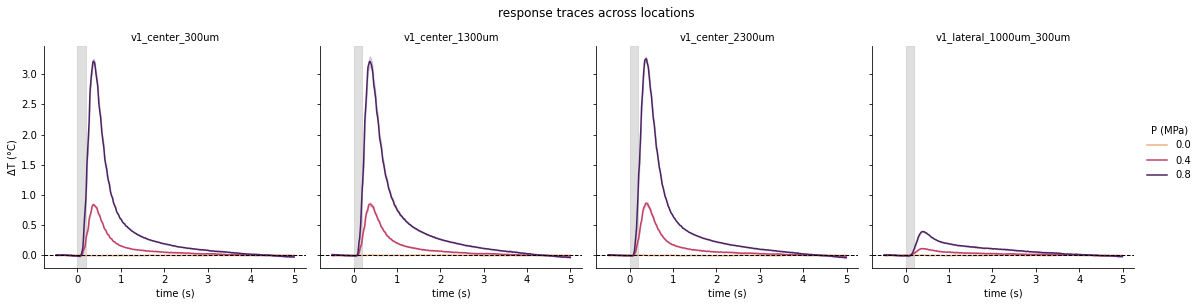

In [6]:
# Plot stim-evoked temperature traces for each xz slice at different y positions,
# color-coded by pressure
hue = Label.P
logger.info('plotting stimulus-evoked temperature traces across locations')
figkey = 'response traces across locations'
g = sns.FacetGrid(
    data=data.reset_index(),
    col='location',
    height=4,
)
g.set_titles(template='{col_name}')
g.map_dataframe(
    plot_evoked_thermal_response,
    y=REL_TEMP_KEY, 
    errorbar='se',
    hue=hue,
    palette='flare',
)
g.add_legend(title=hue)
figs[figkey] = g.figure
figs[figkey].suptitle(figkey, y=1.05)

### Aggregate traces across trials for each condition 

In [7]:
# Aggregate traces across trials for each condition 
aggdata = compute_trial_average(data)
aggdata

 2026/09/15 15:33:17: computing trial-average data by ['location', 'P (MPa)']


Vpp (V)  detrended T (°C)  \
location                P (MPa) time (s)                                
v1_center_1300um        0.0     -0.492275  0.000000         67.634283   
                                -0.483925  0.000000         67.631673   
                                -0.475575  0.000000         67.630382   
                                -0.467225  0.000000         67.632007   
                                -0.458875  0.000000         67.633068   
...                                             ...               ...   
v1_lateral_1000um_300um 0.8      4.960475  0.257133         61.671079   
                                 4.968825  0.257133         61.670027   
                                 4.977175  0.257133         61.669089   
                                 4.985525  0.257133         61.671102   
                                 4.993875  0.257133         61.671798   

                                           Fdrive (MHz)   ΔT (°C)  PRF (Hz)  \
location                P (MPa) time (s)                                      
v1_center_1300um        0.0     -0.492275         2.095  0.003525     100.0   
                                -0.483925         2.095  0.000916     100.0   
                                -0.475575         2.095 -0.000375     100.0   
                                -0.467225         2.095  0.001249     100.0   
                                -0.458875         2.095  0.002311     100.0   
...                                                 ...       ...       ...   
v1_lateral_1000um_300um 0.8      4.960475         2.095 -0.018452     100.0   
                                 4.968825         2.095 -0.019505     100.0   
                                 4.977175         2.095 -0.020442     100.0   
                                 4.985525         2.095 -0.018429     100.0   
                                 4.993875         2.095 -0.017733     100.0   

                                           tstim (s)     T (°C)  DC (%)  
location                P (MPa) time (s)                                 
v1_center_1300um        0.0     -0.492275        0.2  67.643028    80.0  
                                -0.483925        0.2  67.640399    80.0  
                                -0.475575        0.2  67.639088    80.0  
                                -0.467225        0.2  67.640692    80.0  
                                -0.458875        0.2  67.641734    80.0  
...                                              ...        ...     ...  
v1_lateral_1000um_300um 0.8      4.960475        0.2  61.702477    80.0  
                                 4.968825        0.2  61.701570    80.0  
                                 4.977175        0.2  61.700778    80.0  
                                 4.985525        0.2  61.702937    80.0  
                                 4.993875        0.2  61.703778    80.0  

[7896 rows x 8 columns]

### Fit double exponential to temperature data

 2026/09/15 15:33:18: fitting double exponential to trial-averaged temperature traces
 2026/09/15 15:33:18: constructing fitted double exponential traces
 2026/09/15 15:33:18: plotting t0 distribution
 2026/09/15 15:33:18: plotting peak distribution
 2026/09/15 15:33:18: plotting tau_rise distribution
 2026/09/15 15:33:18: plotting tau_decay distribution
 2026/09/15 15:33:18: plotting offset distribution


Text(0.5, 1.05, 'distribution of double exponential fit parameters')

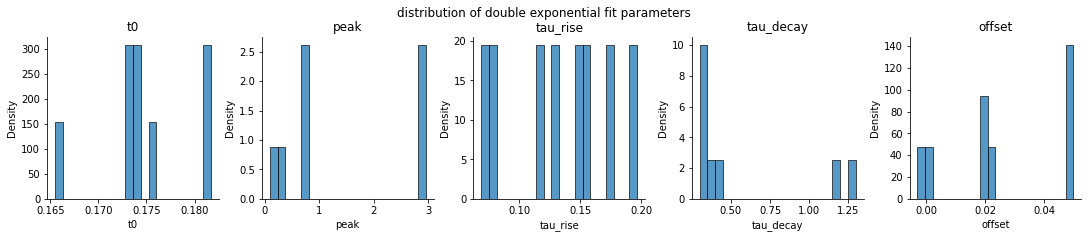

In [8]:
# Compute double exponential fits to the trial-averaged temperature traces
logger.info('fitting double exponential to trial-averaged temperature traces')
gby = [k for k in aggdata.index.names if k != TIME_KEY]
groups = aggdata.groupby(gby)[REL_TEMP_KEY]
fits = groups.apply(fit_double_exp).unstack('parameter')

# Construct fitted double exponential traces
logger.info('constructing fitted double exponential traces')
aggdata[f'fitted {REL_TEMP_KEY}'] = groups.apply(lambda x: pd.Series(
    double_exp_peak(
        x.index.get_level_values(TIME_KEY).values,
        *fits.loc[x.name].values),
    index=x.index.get_level_values(TIME_KEY))
)

naxes = len(fits.columns)
figkey = 'distribution of double exponential fit parameters'
figs[figkey], axes = plt.subplots(1, naxes, figsize=(3 * naxes, 3), constrained_layout=True)
for k, ax in zip(fits.columns, axes):
    logger.info(f'plotting {k} distribution')
    sns.histplot(
        fits[k],
        ax=ax,
        bins=20,
        stat='density',
    )
    ax.set_title(k)
    sns.despine(ax=ax)
figs[figkey].suptitle(figkey, y=1.05)

### Plot trial-averaged stim-evoked temperature traces and fitted double exponential traces

 2026/09/15 15:33:19: plotting stimulus-evoked temperature traces per location


Text(0.5, 1.05, 'trial-average response traces (with double-exponential fits) across locations')

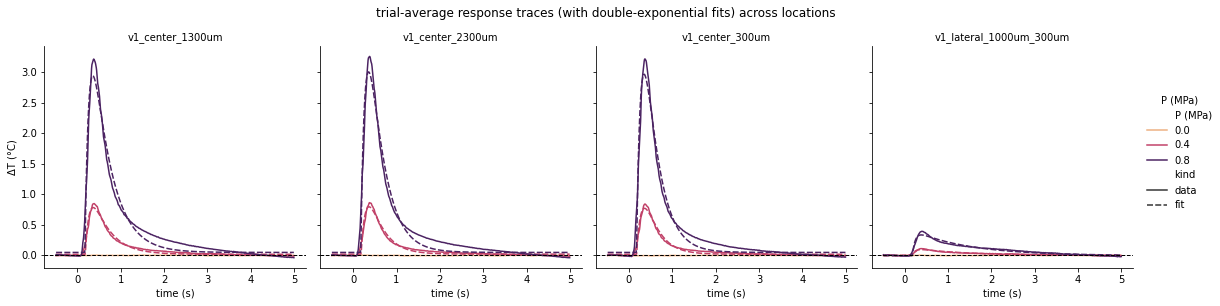

In [9]:
# Melt data by data/fit kind for plotting
ymap = {
    REL_TEMP_KEY: 'data',
    f'fitted {REL_TEMP_KEY}': 'fit'
}
melted_data = melt_by_condition(aggdata, ymap, 'kind')

# Plot stim-evoked temperature traces for each xz slice at different y positions,
# color-coded by pressure
hue = Label.P
logger.info(f'plotting stimulus-evoked temperature traces per location')
figkey = 'trial-average response traces (with double-exponential fits) across locations'
g = sns.FacetGrid(
    data=melted_data.reset_index(),
    col='location',
    height=4,
    sharex=False,
)
g.set_titles(template='{col_name}')
g.map_dataframe(
    plot_evoked_thermal_response,
    y=REL_TEMP_KEY,
    hue=hue,
    palette='flare',
    style='kind',
)
g.add_legend(title=hue)
figs[figkey] = g.figure
figs[figkey].suptitle(figkey, y=1.05)

### Compute max-evoked temperature change for each condition

In [10]:
# Compute max-evoked temperature change for each condition and trial
cond_keys = condition_keys(data)
logger.info('computing max-evoked temperature change for each condition and trial')
max_evoked_change = (
    data
    .groupby([*cond_keys, 'trial'])
    [REL_TEMP_KEY]
    .max()
    .rename(MAX_REL_TEMP_KEY)
)
max_evoked_change

logger.info('computing average max-evoked temperature change for each condition')
agg_max_evoked_change = (
    max_evoked_change
    .groupby(cond_keys)
    .mean()
)

 2026/09/15 15:33:20: computing max-evoked temperature change for each condition and trial
 2026/09/15 15:33:20: computing average max-evoked temperature change for each condition


### Plot dose-dependence of evoked temperature change at each location

 2026/09/15 15:33:20: plotting pressure dependence of temperature change at v1_center_300um
 2026/09/15 15:33:20: plotting pressure-dependent evoked temperature change traces
 2026/09/15 15:33:21: performing quadratic fit on max_ΔT vs pressure
 2026/09/15 15:33:21: plotting dose-dependence of max-evoked temperature change at focus
 2026/09/15 15:33:21: plotting pressure dependence of temperature change at v1_center_1300um
 2026/09/15 15:33:21: plotting pressure-dependent evoked temperature change traces
 2026/09/15 15:33:21: performing quadratic fit on max_ΔT vs pressure
 2026/09/15 15:33:21: plotting dose-dependence of max-evoked temperature change at focus
 2026/09/15 15:33:21: plotting pressure dependence of temperature change at v1_center_2300um
 2026/09/15 15:33:21: plotting pressure-dependent evoked temperature change traces
 2026/09/15 15:33:22: performing quadratic fit on max_ΔT vs pressure
 2026/09/15 15:33:22: plotting dose-dependence of max-evoked temperature change at focus

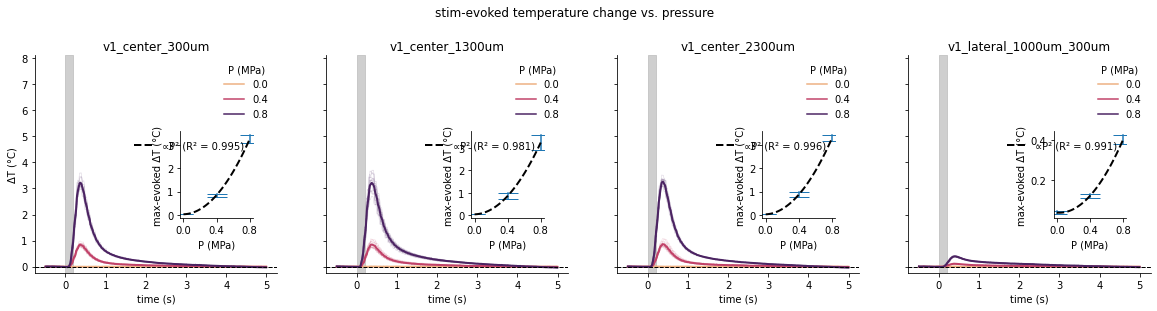

In [11]:
# Plot pressure dependence of temperature change at each location, with quadratic fit and R² value
locs = data.index.unique('location')
naxes = len(locs)
figkey = 'stim-evoked temperature change vs. pressure'
figs[figkey], axes = plt.subplots(1, naxes, figsize=(5 * naxes, 4), sharey=True)
figs[figkey].suptitle(figkey, y=1.05)
for loc, ax in zip(data.index.unique('location'), axes):
    logger.info(f'plotting pressure dependence of temperature change at {loc}')
    loc_data = data.loc[loc]
    loc_max_evoked_change = max_evoked_change.loc[loc]
    plot_pressure_dependence(
        loc_data, loc_max_evoked_change, title=loc, ax=ax)

### Save figures

In [12]:
save_figs_book(figsdir, figs, suffix=experiment)

 2026/09/15 15:33:23: saving figures in /Users/tlemaire/Documents/data/US_thermal_experiments/figs/2026.09.15/figs_20260911_M02.pdf:


100%|██████████| 8/8 [00:01<00:00,  4.23it/s]
